In [8]:
import sys
sys.path.append("../utils/py")
import miniramses as ram

In [9]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt
import miniramses as ram
from miniramses import visu

# -----------------------------
# Matplotlib config
# -----------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 300
plt.rcParams.update({
    "font.size": 20,
    "legend.fontsize": 18,
    "text.usetex": True,
})

# -----------------------------
# Global settings
# -----------------------------
center = np.array([1, 1, 1])


# -----------------------------
# Utilities
# -----------------------------
def normalize_dir(path):
    """Normalize path safely."""
    return os.path.abspath(path)


def infer_isort(prefix):
    """Validate prefix."""
    if prefix is None:
        prefix = "hydro"

    prefix = prefix.lower()

    if prefix in ["hydro", "grav", "rt"]:
        return 0
    elif prefix == "peak":
        return 1
    else:
        raise ValueError(f"Unknown prefix: {prefix}")


def read_output(output_path, center=center):
    """
    Read RAMSES output from full directory path.

    Example:
        /home/.../mini-ramses/output_00004
    """
    output_path = normalize_dir(output_path)

    nout_dir = os.path.basename(output_path)
    base_path = os.path.dirname(output_path)

    if not nout_dir.startswith("output_"):
        raise ValueError(
            f"Expected path like '.../output_00004', got: {output_path}"
        )

    nout = nout_dir.split("_")[-1]
    print("I am reading nout: ", nout)

    candidate_prefixes = ["grav", "hydro", "rt", "peak"]
    last_err = None

    for prefix in candidate_prefixes:
        try:
            infer_isort(prefix)

            c = ram.rd_cell(nout, path=base_path, prefix=prefix, center=center)
            i = ram.rd_info(nout, path=base_path)

            print(f"[OK] {output_path} (prefix='{prefix}')")
            return c, i, prefix

        except Exception as err:
            last_err = err

    raise RuntimeError(
        f"Failed to read {output_path} with known prefixes.\nLast error: {last_err}"
    )




def _display_shift_for_box(x, y, dx, box):
    if box is None:
        half_dx = 0.5 * np.asarray(dx, dtype=float)
        x0 = float(np.nanmin(np.asarray(x, dtype=float) - half_dx))
        x1 = float(np.nanmax(np.asarray(x, dtype=float) + half_dx))
        y0 = float(np.nanmin(np.asarray(y, dtype=float) - half_dx))
        y1 = float(np.nanmax(np.asarray(y, dtype=float) + half_dx))
    else:
        x0, x1, y0, y1 = map(float, box)
    return -x0, -y0, [0.0, x1 - x0, 0.0, y1 - y0]

def _shift_display_xy(x, y, dx, box):
    x_shift, y_shift, display_box = _display_shift_for_box(x, y, dx, box)
    return x + x_shift, y + y_shift, display_box

def amr_slice(c, cen, levels=None):
    """
    Select cells intersecting plane z = cen.
    """
    mask = np.abs(c.x[2] - cen) <= c.dx / 2

    if levels is not None:
        mask &= np.isin(c.level, levels)

    x = c.x[0][mask]
    y = c.x[1][mask]
    dx = c.dx[mask]

    return x, y, dx, mask


# -----------------------------
# Plot single output
# -----------------------------
def plot(output_path, cen=600, levels=None, field_index=0, **visu_kwargs):
    """
    Plot one output.

    Parameters
    ----------
    output_path : str
        Path to output directory
    cen : float
        z-slice center
    levels : list or None
        AMR levels to include
    field_index : int
        which component of c.g to plot
    """

    print("Reading:", output_path)

    c, i, prefix = read_output(output_path, center=center)

    print("Levels:", np.unique(c.level))
    x, y, dx, mask = amr_slice(c, cen, levels)

    val = c.g[field_index][mask]
    lev = c.level[mask]

    box = visu_kwargs.get("box", None)
    x_plot, y_plot, display_box = _shift_display_xy(x, y, dx, box)
    visu_kwargs = dict(visu_kwargs)
    visu_kwargs["box"] = display_box

    return ram.visu(x_plot, y_plot, dx, val, lev, **visu_kwargs)


# -----------------------------
# Compare two outputs
# -----------------------------
def compare(output_path, base_output_path, cen=600, levels=None, field_index=0, **visu_kwargs):
    """
    Compare two outputs (difference plot).
    """

    print("Target:", output_path)
    print("Base  :", base_output_path)

    c, _, _ = read_output(output_path, center=center)
    c_base, _, _ = read_output(base_output_path, center=center)

    x, y, dx, mask = amr_slice(c, cen, levels)

    diff = c.g[field_index] - c_base.g[field_index]
    val = diff[mask]
    lev = c.level[mask]

    box = visu_kwargs.get("box", None)
    x_plot, y_plot, display_box = _shift_display_xy(x, y, dx, box)
    visu_kwargs = dict(visu_kwargs)
    visu_kwargs["box"] = display_box

    out = ram.visu(x_plot, y_plot, dx, val, lev, **visu_kwargs)

    denom = c_base.g[field_index][mask]
    good = denom != 0

    if np.any(good):
        rel = val[good] / denom[good]
        print("mean relative error :", np.mean(rel))
        print("median relative error:", np.median(rel))
    else:
        print("Relative error undefined (denominator zero everywhere)")

    return out

In [10]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt
import miniramses as ram

# -----------------------------
# Matplotlib config
# -----------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 800
plt.rcParams.update({
    "font.size": 20,
    "legend.fontsize": 18,
})

# -----------------------------
# Global settings
# -----------------------------
center = np.array([1, 1, 1])


# -----------------------------
# Utilities
# -----------------------------
def normalize_dir(path):
    """Normalize path safely."""
    return os.path.abspath(path)


def infer_isort(prefix):
    """Validate prefix."""
    if prefix is None:
        prefix = "hydro"

    prefix = prefix.lower()

    if prefix in ["hydro", "grav", "rt"]:
        return 0
    elif prefix == "peak":
        return 1
    else:
        raise ValueError(f"Unknown prefix: {prefix}")


def read_output(output_path, center=center):
    """
    Read RAMSES output from full directory path.

    Example:
        /home/.../mini-ramses/output_00004
    """
    output_path = normalize_dir(output_path)

    nout_dir = os.path.basename(output_path)
    base_path = os.path.dirname(output_path)

    if not nout_dir.startswith("output_"):
        raise ValueError(
            f"Expected path like '.../output_00004', got: {output_path}"
        )

    nout = nout_dir.split("_")[-1]
    print("I am reading nout: ", nout)

    candidate_prefixes = ["grav", "hydro", "rt", "peak"]
    last_err = None

    for prefix in candidate_prefixes:
        try:
            infer_isort(prefix)

            c = ram.rd_cell(nout, path=base_path, prefix=prefix, center=center)
            i = ram.rd_info(nout, path=base_path)

            print(f"[OK] {output_path} (prefix='{prefix}')")
            return c, i, prefix

        except Exception as err:
            last_err = err

    raise RuntimeError(
        f"Failed to read {output_path} with known prefixes.\nLast error: {last_err}"
    )




def _display_shift_for_box(x, y, dx, box):
    if box is None:
        half_dx = 0.5 * np.asarray(dx, dtype=float)
        x0 = float(np.nanmin(np.asarray(x, dtype=float) - half_dx))
        x1 = float(np.nanmax(np.asarray(x, dtype=float) + half_dx))
        y0 = float(np.nanmin(np.asarray(y, dtype=float) - half_dx))
        y1 = float(np.nanmax(np.asarray(y, dtype=float) + half_dx))
    else:
        x0, x1, y0, y1 = map(float, box)
    return -x0, -y0, [0.0, x1 - x0, 0.0, y1 - y0]

def _shift_display_xy(x, y, dx, box):
    x_shift, y_shift, display_box = _display_shift_for_box(x, y, dx, box)
    return x + x_shift, y + y_shift, display_box

def amr_slice(c, cen, levels=None):
    """
    Select cells intersecting plane z = cen.
    """
    mask = np.abs(c.x[2] - cen) <= c.dx / 2

    if levels is not None:
        mask &= np.isin(c.level, levels)

    x = c.x[0][mask]
    y = c.x[1][mask]
    dx = c.dx[mask]

    return x, y, dx, mask


# -----------------------------
# Plot single output
# -----------------------------
def plot(output_path, cen=600, levels=None, field_index=0, **visu_kwargs):
    """
    Plot one output.
    """

    print("Reading:", output_path)

    c, i, prefix = read_output(output_path, center=center)

    print("Levels:", np.unique(c.level))
    x, y, dx, mask = amr_slice(c, cen, levels)

    val = c.g[field_index][mask]
    lev = c.level[mask]

    box = visu_kwargs.get("box", None)
    x_plot, y_plot, display_box = _shift_display_xy(x, y, dx, box)
    visu_kwargs = dict(visu_kwargs)
    visu_kwargs["box"] = display_box

    return ram.visu(x_plot, y_plot, dx, val, lev, **visu_kwargs)


# -----------------------------
# Compare two outputs
# -----------------------------
def compare(output_path, base_output_path, cen=600, levels=None, field_index=0, **visu_kwargs):
    """
    Compare two outputs.

    Difference is target - base.
    """

    print("Target:", output_path)
    print("Base  :", base_output_path)

    c, _, _ = read_output(output_path, center=center)
    c_base, _, _ = read_output(base_output_path, center=center)

    x, y, dx, mask = amr_slice(c, cen, levels)

    diff = c.g[field_index] - c_base.g[field_index]
    val = diff[mask]
    lev = c.level[mask]

    box = visu_kwargs.get("box", None)
    x_plot, y_plot, display_box = _shift_display_xy(x, y, dx, box)
    visu_kwargs = dict(visu_kwargs)
    visu_kwargs["box"] = display_box

    out = ram.visu(x_plot, y_plot, dx, val, lev, **visu_kwargs)

    denom = c_base.g[field_index][mask]
    good = denom != 0

    if np.any(good):
        rel = val[good] / denom[good]
        print("mean relative error :", np.mean(rel))
        print("median relative error:", np.median(rel))
    else:
        print("Relative error undefined, denominator zero everywhere")

    return out

In [11]:
def panel_mg_fmm_percent(
    fmm_output_path,
    mg_output_path,
    cen=600,
    levels=None,
    field_index=0,
    vmin=None,
    vmax=None,
    diff_vmin=-10,
    diff_vmax=10,
    cmap="magma",
    diff_cmap="RdBu_r",
    npix=1200,
    grid=True,
    box=None,
    figsize=(15, 5),
    phi_label="x",   # NEW: gives \Phi_{\rm x}, \Phi_{\rm y}, etc.
    save=None,
):
    """
    Three-panel plot:

        MG | FMM | 100 * (MG - FMM) / MG

    Positive percent means MG > FMM.
    """

    print("Reading FMM:", fmm_output_path)
    c_fmm, _, _ = read_output(fmm_output_path, center=center)

    print("Reading MG:", mg_output_path)
    c_mg, _, _ = read_output(mg_output_path, center=center)

    print("FMM levels:", np.unique(c_fmm.level))
    print("MG levels :", np.unique(c_mg.level))

    # Use FMM slice geometry
    x, y, dx, mask = amr_slice(c_fmm, cen, levels)
    lev = c_fmm.level[mask]

    fmm_val = c_fmm.g[field_index][mask]
    mg_val  = c_mg.g[field_index][mask]

    x_plot, y_plot, display_box = _shift_display_xy(x, y, dx, box)

    # Percent difference
    percent = np.full_like(mg_val, np.nan, dtype=float)
    good = mg_val != 0.0
    percent[good] = 100.0 * (mg_val[good] - fmm_val[good]) / mg_val[good]

    print("Percent difference: 100 * (MG - FMM) / MG")
    if np.any(np.isfinite(percent)):
        print("mean percent difference   :", np.nanmean(percent))
        print("median percent difference :", np.nanmedian(percent))
        print("min percent difference    :", np.nanmin(percent))
        print("max percent difference    :", np.nanmax(percent))
    else:
        print("Percent difference undefined")

    # Absolute summary stats for annotation
    finite_percent = percent[np.isfinite(percent)]
    if finite_percent.size > 0:
        max_abs_percent  = np.nanmax(np.abs(finite_percent))
        mean_abs_percent = np.nanmean(np.abs(finite_percent))
    else:
        max_abs_percent  = np.nan
        mean_abs_percent = np.nan

    # Shared MG/FMM scale
    if vmin is None:
        vmin = np.nanmin([np.nanmin(mg_val), np.nanmin(fmm_val)])
    if vmax is None:
        vmax = np.nanmax([np.nanmax(mg_val), np.nanmax(fmm_val)])

    fig, axes = plt.subplots(
        1,
        3,
        figsize=figsize,
        dpi=300,
        constrained_layout=True,
    )

    # -----------------------------
    # MG
    # -----------------------------
    _, _, im0 = visu(
        x_plot,
        y_plot,
        dx,
        mg_val,
        lev,
        ax=axes[0],
        npix=npix,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        box=display_box,
        grid=grid,
        colorbar=False,
    )
    axes[0].set_title("MG")
    axes[0].set_xlabel(r"$x$")
    axes[0].set_ylabel(r"$y$")

    # -----------------------------
    # FMM
    # -----------------------------
    _, _, im1 = visu(
        x_plot,
        y_plot,
        dx,
        fmm_val,
        lev,
        ax=axes[1],
        npix=npix,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        box=display_box,
        grid=grid,
        colorbar=False,
    )
    axes[1].set_title("FMM")
    axes[1].set_xlabel(r"$x$")
    
    # -----------------------------
    # Percentage difference
    # -----------------------------
    _, _, im2 = visu(
        x_plot,
        y_plot,
        dx,
        percent,
        lev,
        ax=axes[2],
        npix=npix,
        cmap=diff_cmap,
        vmin=diff_vmin,
        vmax=diff_vmax,
        box=display_box,
        grid=grid,
        colorbar=False,
    )
    axes[2].set_xlabel(r"$x$")

    # Add top annotation on third panel
    axes[2].text(
        0.5,
        1.00,
        rf"max: {max_abs_percent:.2f}$\%$, mean: {mean_abs_percent:.2f}$\%$",
        transform=axes[2].transAxes,
        ha="center",
        va="bottom",
        fontsize=20,
    )
    
    axes[1].set_yticks([])
    axes[2].set_yticks([])
    # Shared colorbar for MG and FMM
    cbar0 = fig.colorbar(
        im0,
        ax=axes[:2],
        shrink=0.82,
        pad=0.02,
    )
    cbar0.set_label(rf"$\Phi$")

    # Colorbar for percent panel
    cbar1 = fig.colorbar(
        im2,
        ax=axes[2],
        shrink=0.82,
        pad=0.02,
    )
    cbar1.set_label(
        rf"$100(\Phi_{{\rm MG}}-\Phi_{{\rm FMM}})/\Phi_{{\rm MG}}$ [\%]"
    )
    if save is not None:
        fig.savefig(save, bbox_inches="tight", dpi=300)
        print(f"Saved figure to {save}")

    return fig, axes

In [12]:
#nout =  '3'  # fmm (7,8) ! pre-direct-multipole expansion
#nout =  '4'  # multgrid  (7,8)
#nout =  '5'  # multigrid (8,8)
#nout =  '6'  # fmm (8,8)
#nout =  '23'  # fmm (7,8,9) ! pre-direct-multipole expansion
#nout =  '24'  # multgrid  (7,8,9)

Reading FMM: /home/jl4415/mini-ramses/halo_single/mg/output_00002/
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=10
Time= 0.00127420375517021
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1314643 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/halo_single/mg/output_00002 (prefix='grav')
Reading MG: /home/jl4415/mini-ramses/halo_single/fmm/output_00002/
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=10
Time= 0.00127420375517021
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1314643 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/halo_single/fmm/output_00002 (prefix='grav')
FMM levels: [6 7 8 9]
MG levels : [6 7 8 9]
Percent difference: 100 * (MG - FMM) / MG
mean percent difference   : -0.5085315882038817
median percent difference : -0.48490699396485126
min percent difference    : -1.5

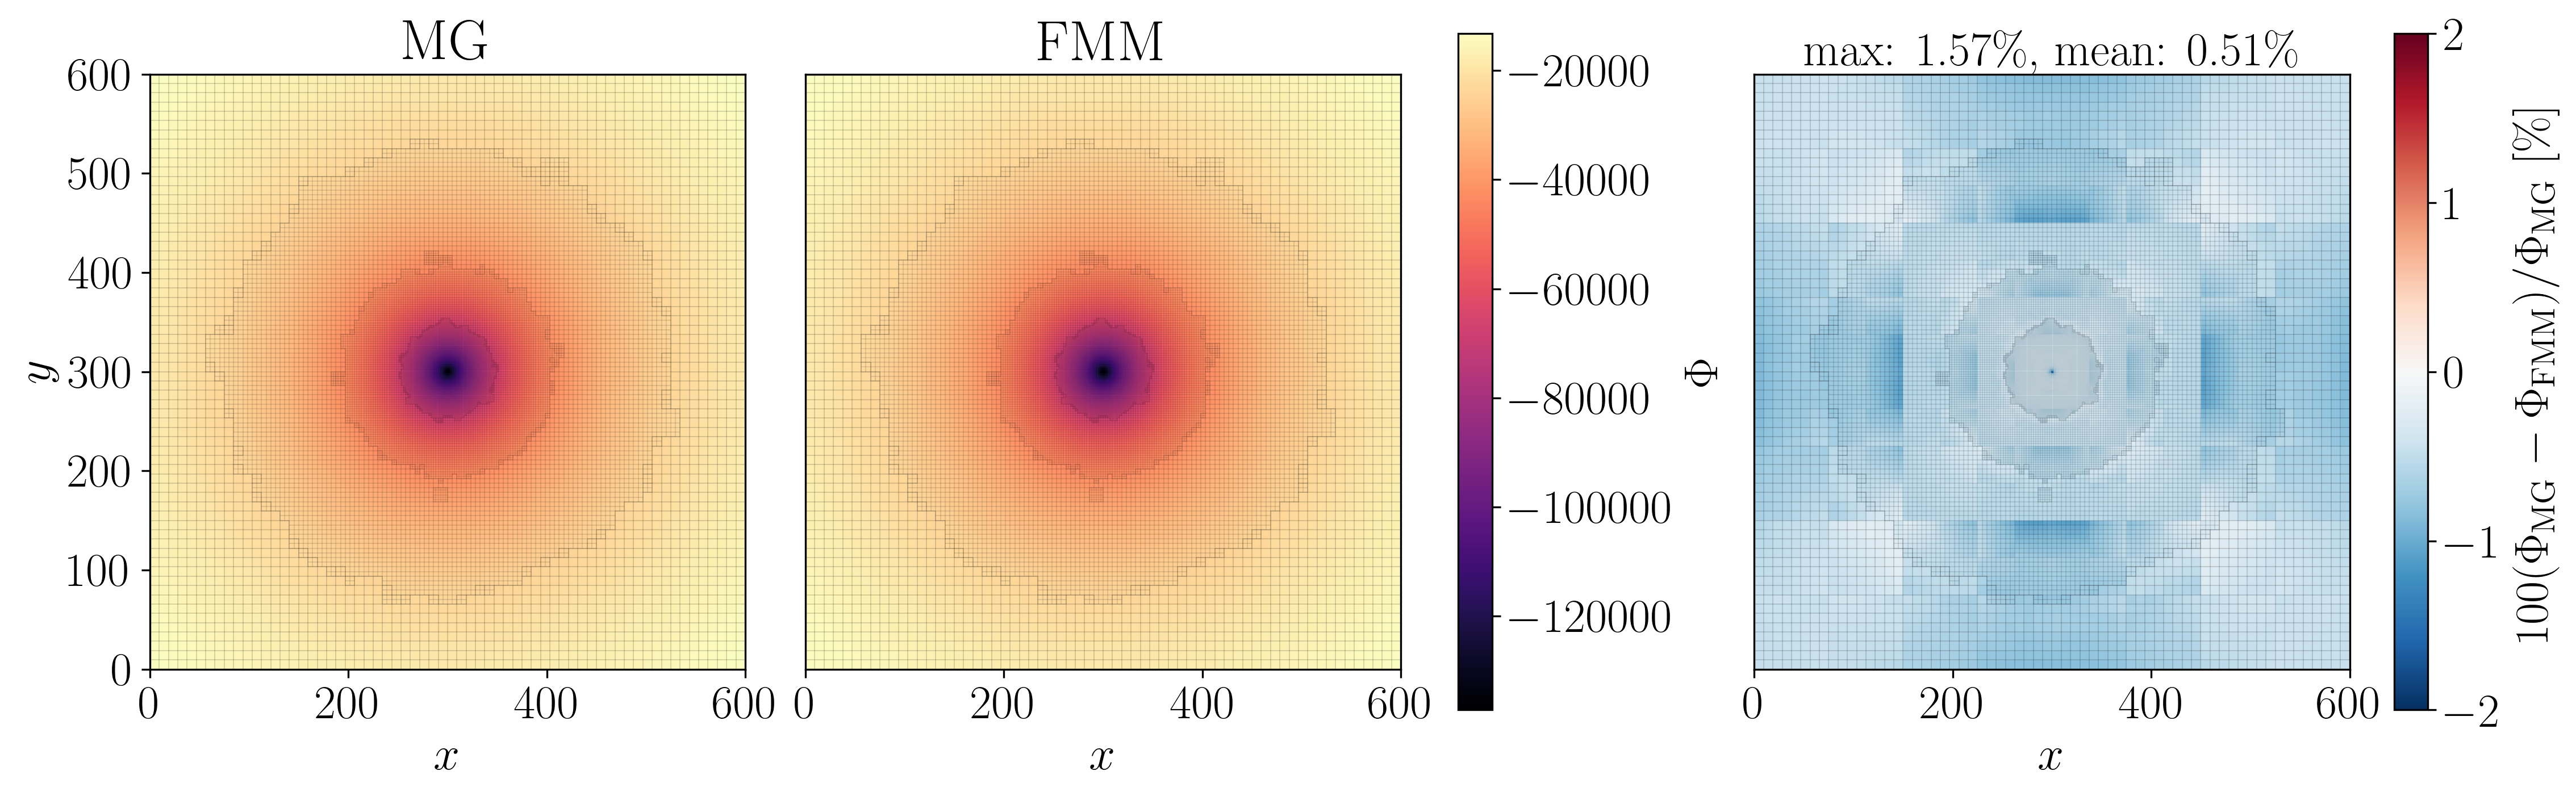

In [13]:
out1 = "/home/jl4415/mini-ramses/halo_single/mg/output_00002/"
out2 = "/home/jl4415/mini-ramses/halo_single/fmm/output_00002/"

fig, axes = panel_mg_fmm_percent(
    fmm_output_path=out1,
    mg_output_path=out2,
    cen=600,
    levels=None,
    field_index=0,
    diff_vmin=-2,
    diff_vmax=2,
    save="fig/halo_amr.png",
)

Reading FMM: /home/jl4415/mini-ramses/shift_halo/mg/output_00002/
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 16777216 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/shift_halo/mg/output_00002 (prefix='grav')
Reading MG: /home/jl4415/mini-ramses/shift_halo/fmm/output_00002/
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 16777216 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/shift_halo/fmm/output_00002 (prefix='grav')
FMM levels: [8]
MG levels : [8]
Percent difference: 100 * (MG - FMM) / MG
mean percent difference   : -0.3394019085155856
median percent difference : -0.2376775344321334
min percent difference    : -4.934041991531446
ma

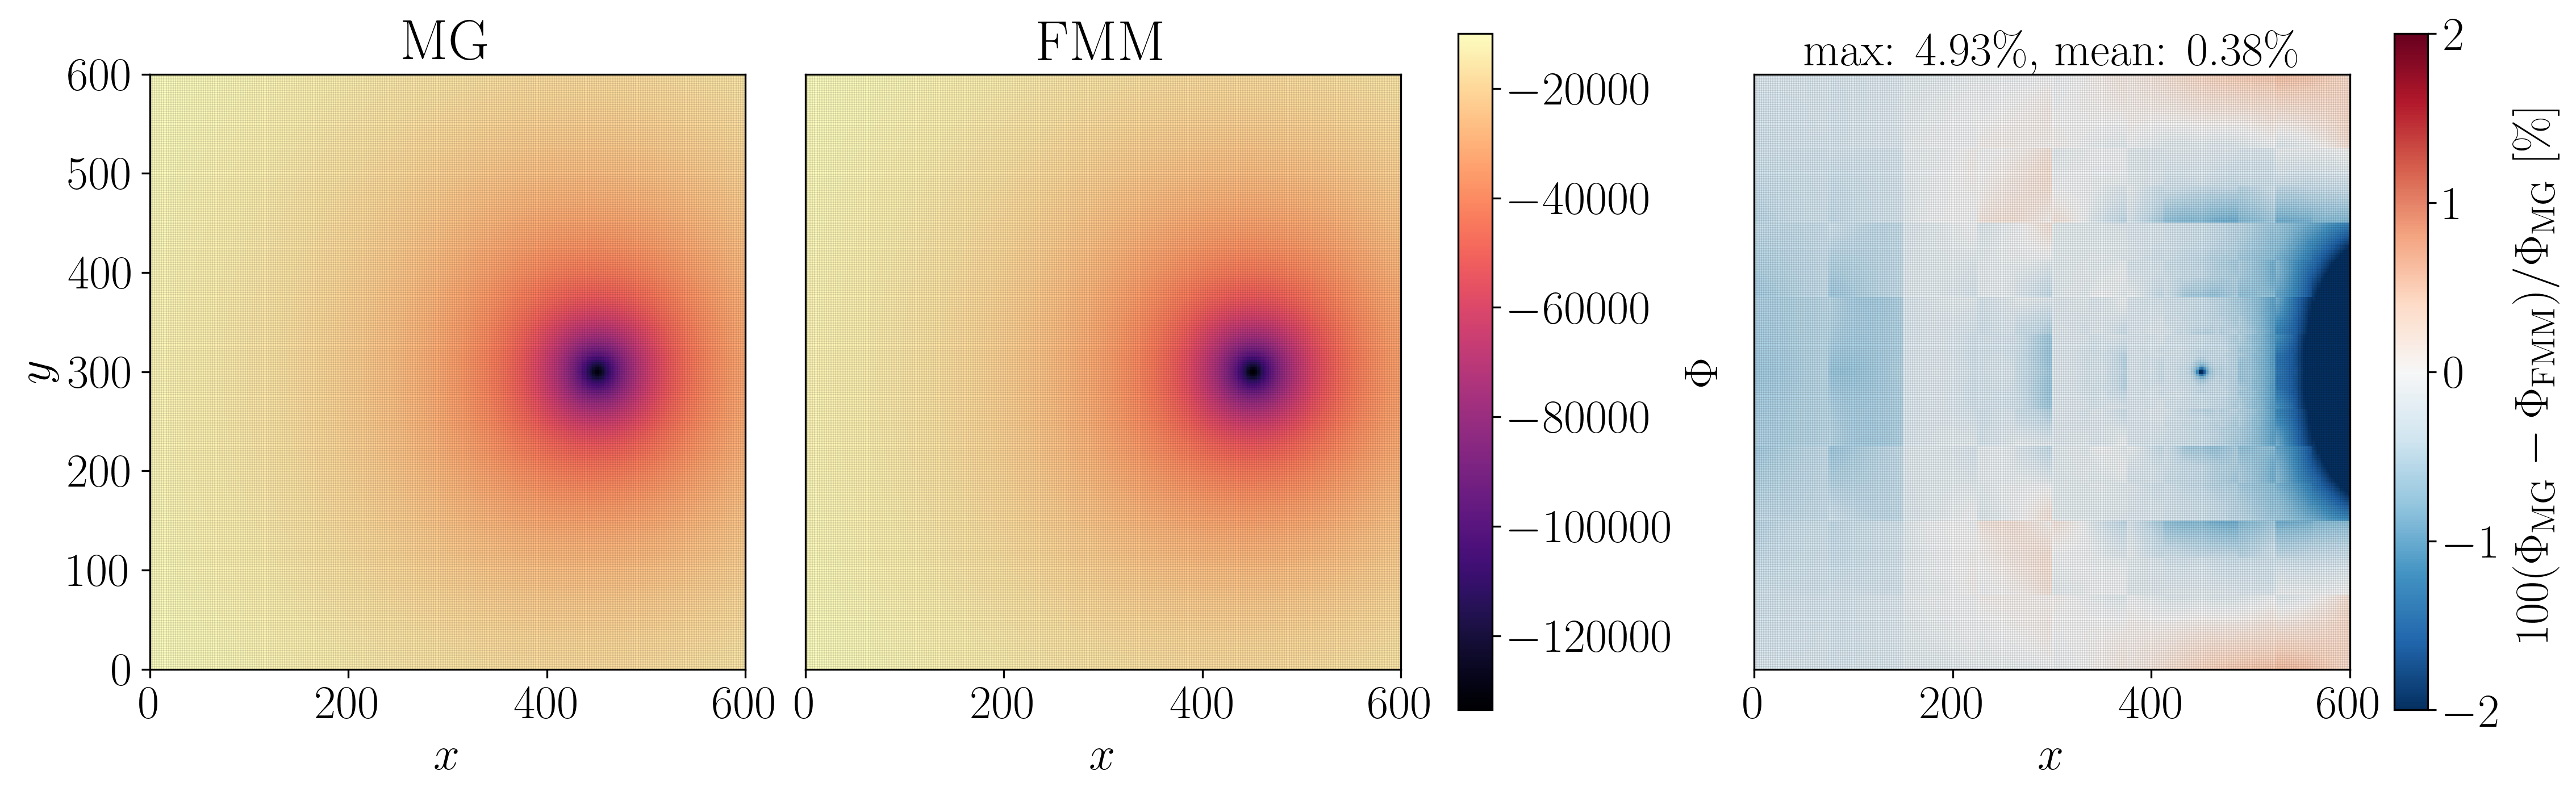

In [14]:
out1 = "/home/jl4415/mini-ramses/shift_halo/mg/output_00002/"
out2 = "/home/jl4415/mini-ramses/shift_halo/fmm/output_00002/"

fig, axes = panel_mg_fmm_percent(
    fmm_output_path=out1,
    mg_output_path=out2,
    cen=600,
    levels=None,
    field_index=0,
    diff_vmin=-2,
    diff_vmax=2,
    save="fig/halo_amr.png",
)

Target: /home/jl4415/mini-ramses/halo_single/mg/output_00002/
Base  : /home/jl4415/mini-ramses/halo_single/fmm/output_00002/
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=10
Time= 0.00127420375517021
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1314643 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/halo_single/mg/output_00002 (prefix='grav')
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=10
Time= 0.00127420375517021
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1314643 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/halo_single/fmm/output_00002 (prefix='grav')
subset value range: -2124.71875 -44.666015625
image range: -2124.71875 -44.666015625
spatial box: [300.0, 900.0, 300.0, 900.0]
mean relative error : 0.005085315882038816
median relative error: 0.004849069939648513


(<Figure size 1200x1200 with 2 Axes>,
 <AxesSubplot:>,
 <matplotlib.image.AxesImage at 0x15075da66130>)

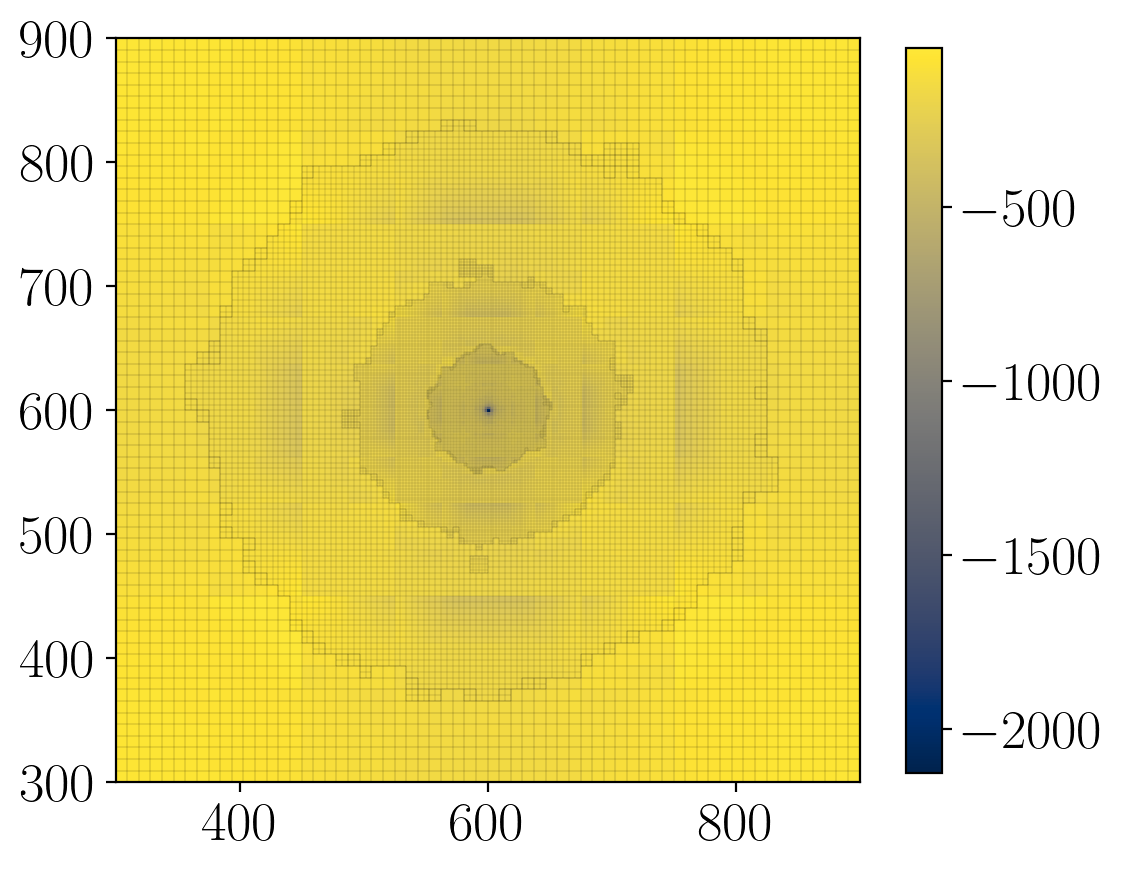

In [7]:
out1 = "/home/jl4415/mini-ramses/halo_single/mg/output_00002/"
out2 = "/home/jl4415/mini-ramses/halo_single/fmm/output_00002/"

compare(
    out1, out2,
    cen=600.0,
    cmap="cividis",
    grid=True
)

Reading: /home/jl4415/mini-ramses/dice_halo/output_00002/
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=10
Time= 0.505444592916532
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 771793 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/dice_halo/output_00002 (prefix='grav')
Levels: [6 7 8 9]
subset value range: -24.543731689453125 -5.402801036834717
image range: -24.540802001953125 -5.402804374694824
spatial box: [50.0, 150.0, 50.0, 150.0]


(<Figure size 1200x1200 with 2 Axes>,
 <AxesSubplot:>,
 <matplotlib.image.AxesImage at 0x153d3d42f7c0>)

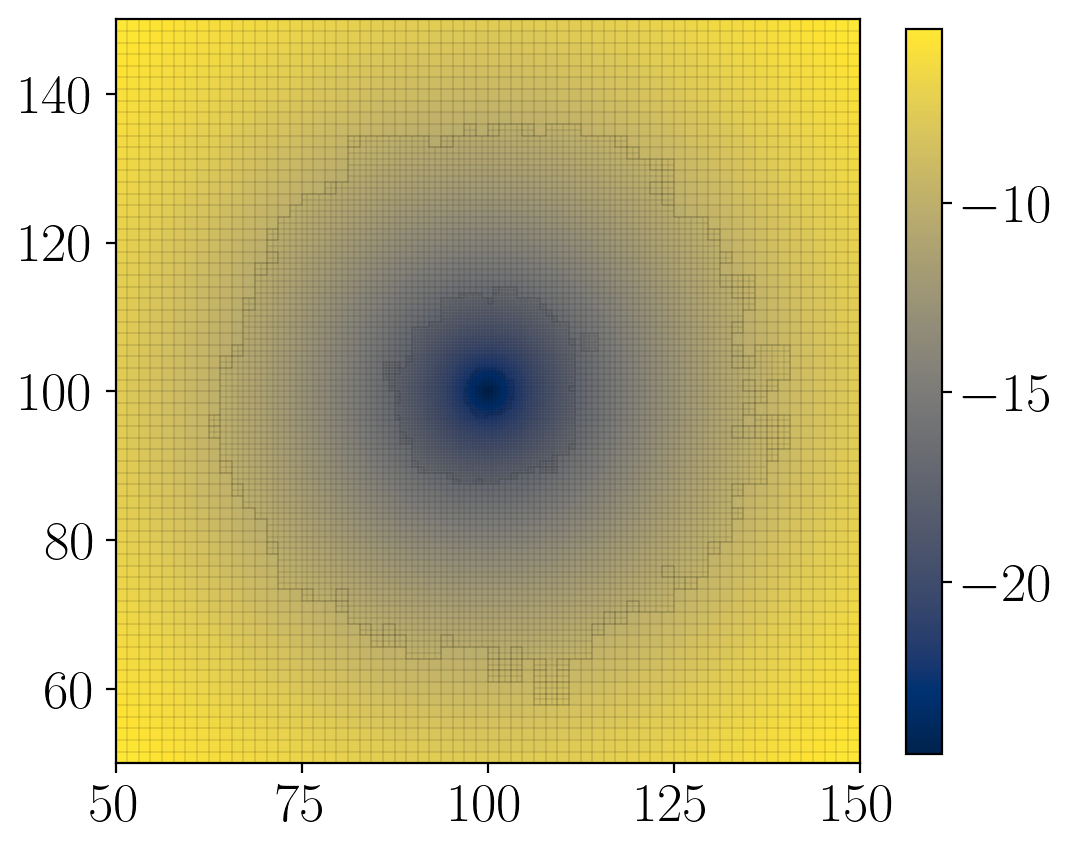

In [10]:
out1 = "/home/jl4415/mini-ramses/dice_halo/output_00002/"

plot(
    out1,
    cen=100.0,
    cmap="cividis",
    grid=True
)

In [7]:
import os
import imageio
import numpy as np
from PIL import Image, ImageDraw, ImageFont

base_dir = "/home/jl4415/mini-ramses/halo_test"

mg_gif = os.path.join(base_dir, "halo_mg", "fig", "animation.gif")
fmm_gif = os.path.join(base_dir, "halo_fmm", "fig", "animation.gif")

out_gif = os.path.join(base_dir, "comparison.gif")

# read gifs
mg_reader = imageio.get_reader(mg_gif)
fmm_reader = imageio.get_reader(fmm_gif)

n_frames = min(mg_reader.get_length(), fmm_reader.get_length())

frames = []

# try font
try:
    font = ImageFont.truetype("DejaVuSans-Bold.ttf", 60)
except:
    font = ImageFont.load_default()

for i in range(n_frames):
    mg_frame = Image.fromarray(mg_reader.get_data(i))
    fmm_frame = Image.fromarray(fmm_reader.get_data(i))
    
    # match heights
    if mg_frame.size[1] != fmm_frame.size[1]:
        fmm_frame = fmm_frame.resize(
            (int(fmm_frame.size[0] * mg_frame.size[1] / fmm_frame.size[1]), mg_frame.size[1])
        )
    
    total_width = mg_frame.size[0] + fmm_frame.size[0]
    max_height = mg_frame.size[1]
    
    # add space on top for titles
    combined = Image.new("RGB", (total_width, max_height + 60), (255, 255, 255))
    
    combined.paste(mg_frame, (0, 60))
    combined.paste(fmm_frame, (mg_frame.size[0], 60))
    
    draw = ImageDraw.Draw(combined)
    
    # titles
    draw.text((mg_frame.size[0] // 2 - 40, 10), "MG", fill="black", font=font)
    draw.text((mg_frame.size[0] + fmm_frame.size[0] // 2 - 50, 10), "FMM", fill="black", font=font)
    
    frames.append(np.array(combined))

# save gif
imageio.mimsave(out_gif, frames, duration=0.5)

print(f"Saved combined GIF to: {out_gif}")

Saved combined GIF to: /home/jl4415/mini-ramses/halo_test/comparison.gif


Reading output 24 and base 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
subset value range: -3277.7578125 58.9609375
image range: -3277.7578125 39.625
spatial box: [356.25, 834.375, 365.625, 834.375]
mean relative error: 0.004017512853322425
median relative error: 0.0037571818978789397


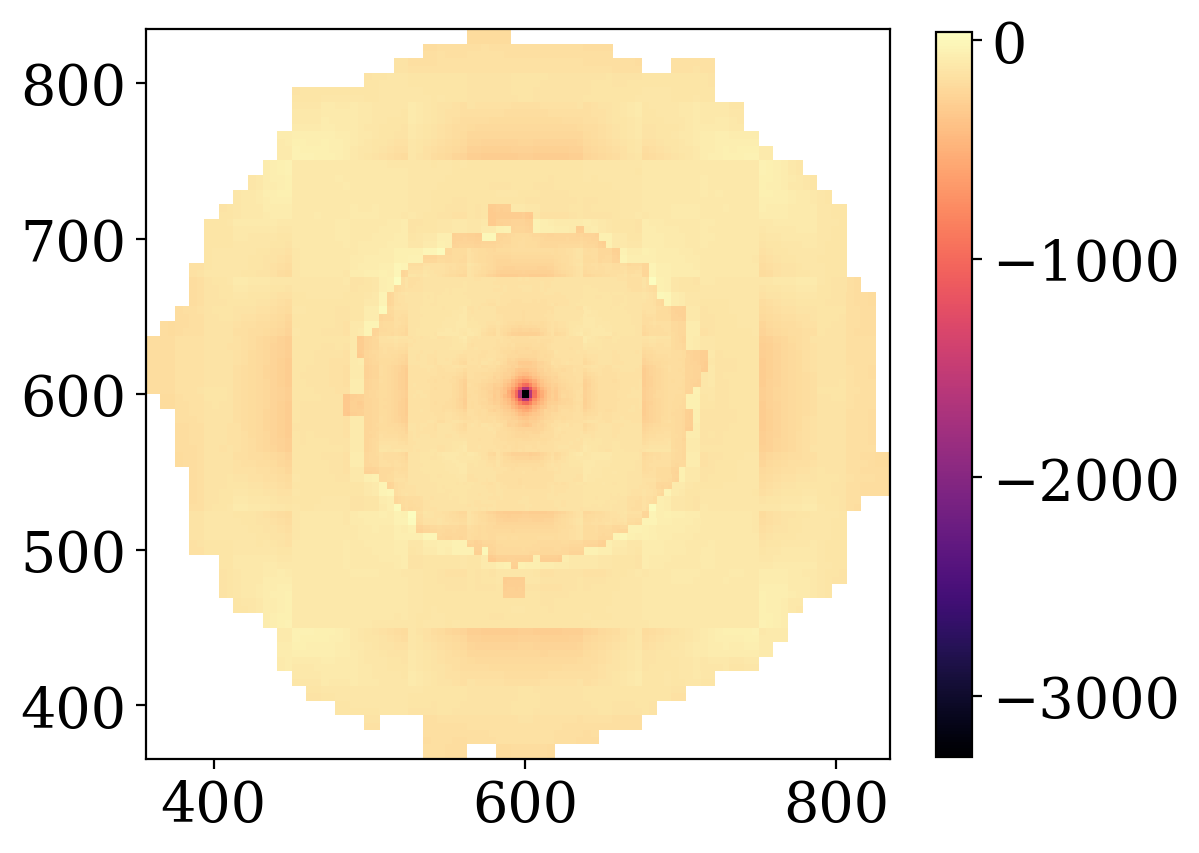

In [5]:
compare(24, 23, 600, levels=[7,8], grid=False)
plt.savefig("./fig/lev78.png")
#mk_image // project

Reading output 24 and base 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
subset value range: -3277.7578125 58.9609375
image range: -3277.7578125 39.625
spatial box: [300.0, 900.0, 300.0, 900.0]
mean relative error: 0.003992840508452441
median relative error: 0.0037402271830726244


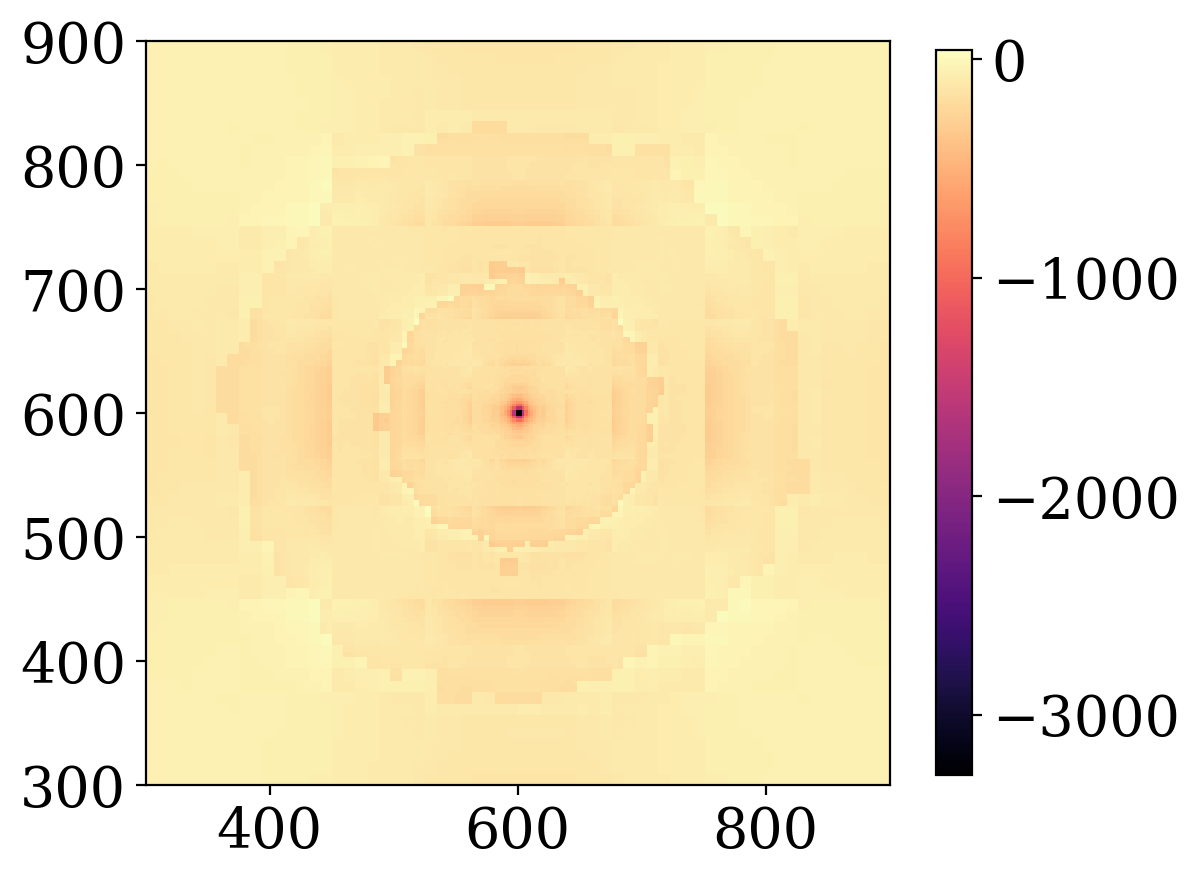

In [6]:
c = compare(24, 23, 600, grid=False, levels=[6,7,8])
plt.savefig("./fig/lev678.png")
#mk_image // project

Reading output 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
Available levels: [6 7 8]
subset value range: -130217.2109375 -37048.78125
image range: -130217.2109375 -37048.78125
spatial box: [300, 900, 300, 900]
Reading output 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
Available levels: [6 7 8]
subset value range: -44965.15234375 -22240.92578125
image range: -44965.15234375 -22240.92578125
spatial box: [300, 900, 300, 900]
Reading output 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 le

(<Figure size 1200x1200 with 2 Axes>,
 <AxesSubplot:>,
 <matplotlib.image.AxesImage at 0x14e633618af0>)

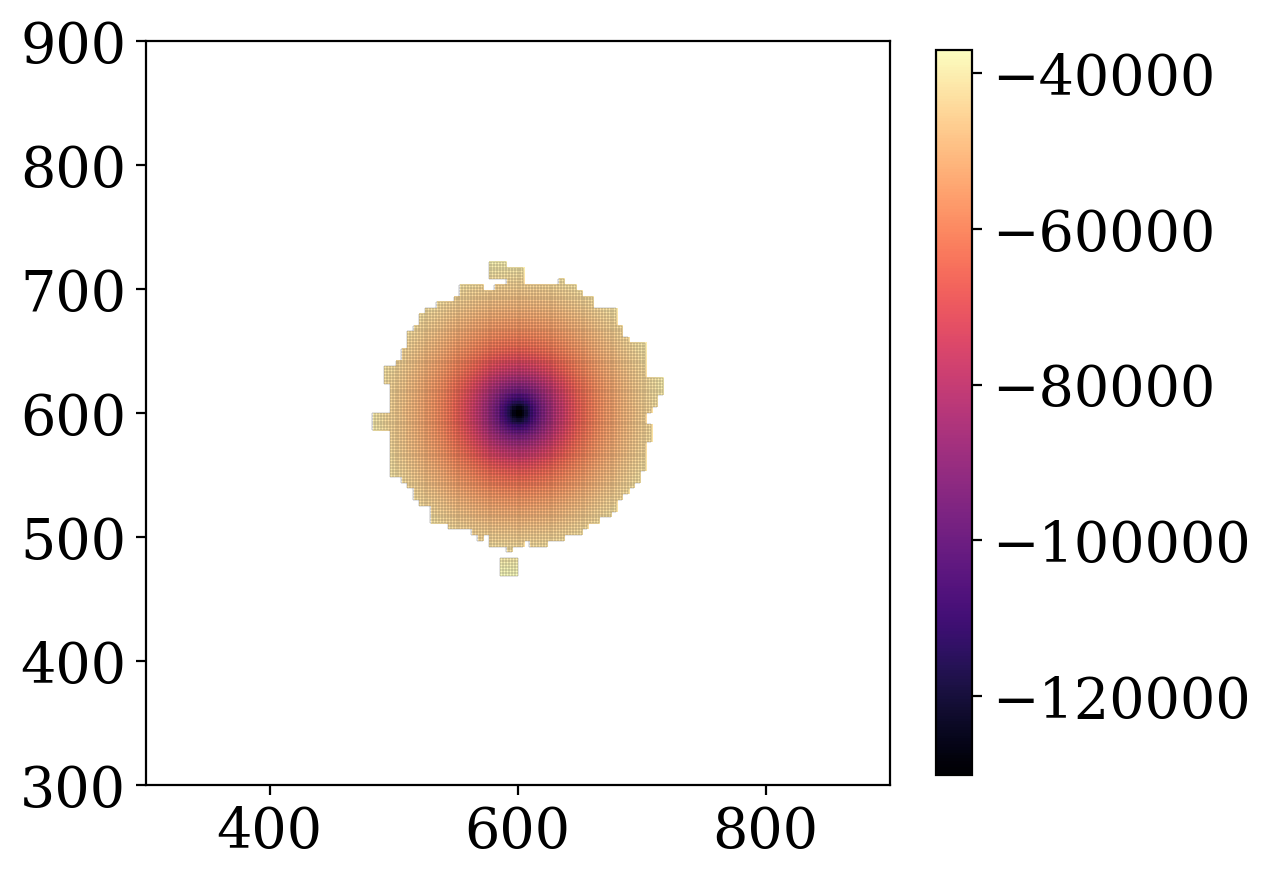

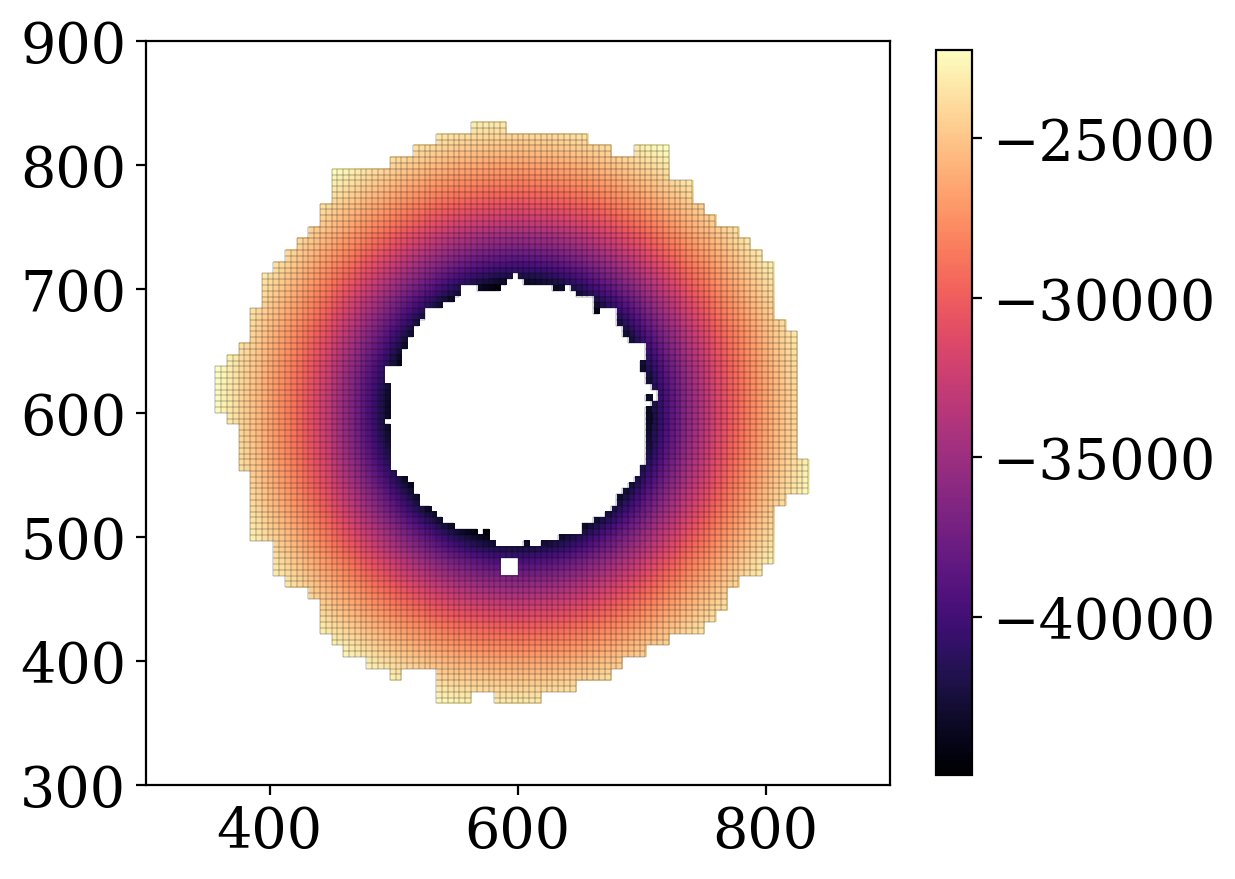

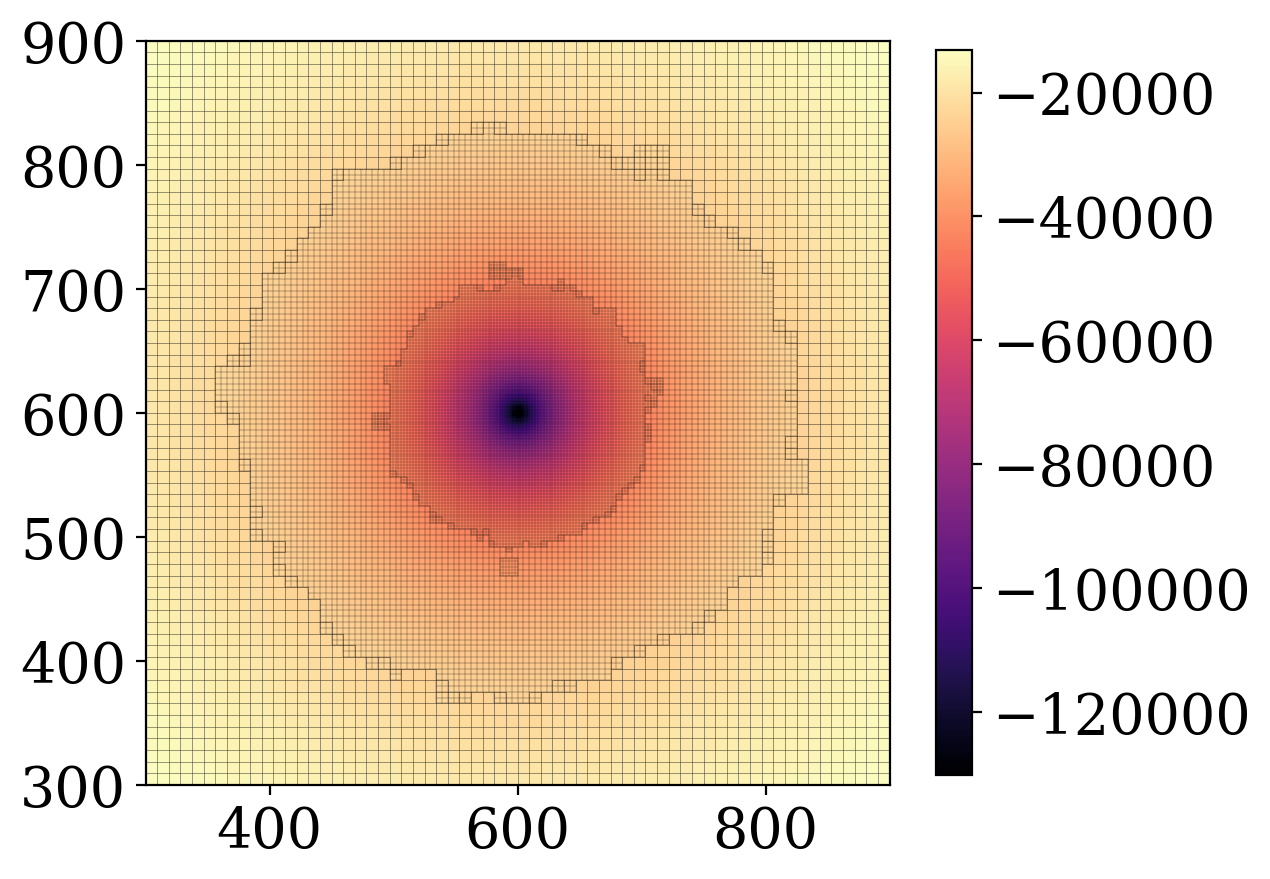

In [7]:
box = [300, 900, 300, 900]

plot(23, 600, grid=True, levels=[8], box=box)
plot(23, 600, grid=True, levels=[7], box=box)
plot(23, 600, grid=True, levels=[6, 7, 8], box=box)

In [ ]:
#mg
'''
     seconds         %    STEP
       0.127       1.0    refine                  
       2.844      21.4    rho                     
       7.502      56.4    poisson                 
       2.797      21.0    particle - kickdrift    
       0.030       0.2    time step               
      13.300     100.0    TOTAL
'''

In [ ]:
#fmm

'''
     seconds         %    STEP
       0.068       0.5    refine                  
       3.020      23.7    rho                     
       7.583      59.6    poisson                 
       0.108       0.9    grav force              
       1.896      14.9    particle - kickdrift    
       0.028       0.2    time step               
       0.017       0.1    recursive call          
      12.721     100.0    TOTAL
'''